# Airline Route Profitability & Cost Analysis
## End-to-End Machine Learning Project

### Objective
This project aims to:
- Understand factors affecting airline route profitability
- Build predictive models for profit estimation
- Classify routes as profitable or unprofitable
- Identify key cost drivers
- Create a what-if simulator for business planning

### Dataset Description
- **File**: airline_route_profitability.csv
- **Scope**: Historical flight data with revenue, costs, and operational metrics
- **Target Variables**: Profit (Regression) and Profitability (Classification)
- **Features**: Aircraft, passengers, costs, seasonal factors, route characteristics

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Data Loading

In [2]:
# Load the dataset
df = pd.read_csv('airline_route_profitability.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst Few Rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())

Dataset Shape: (7974, 33)

First Few Rows:
  Flight_Number Flight_Date Origin Destination    Route     Aircraft_Type  \
0        EK8960  2024-12-20    DXB         ORD  DXB-ORD  Boeing 777-300ER   
1        EK3960  2024-05-13    DXB         HYD  DXB-HYD      Boeing 787-9   
2        EK7529  2024-10-12    DXB         CDG  DXB-CDG      Boeing 787-9   
3        EK4543  2024-06-25    DXB         DEL  DXB-DEL      Boeing 787-9   
4        EK3114  2024-04-20    DXB         RUH  DXB-RUH       Airbus A320   

   Aircraft_Capacity  Passengers  Load_Factor  Flight_Hours    Season  \
0                396         308       0.7791          14.5      Peak   
1                296         234       0.7910           4.2    Normal   
2                296         251       0.8502           7.5  Shoulder   
3                296         229       0.7748           3.5       Low   
4                180         142       0.7901           2.2  Shoulder   

  Route_Category Demand_Level  Ticket_Revenue  Ancillar

## 3. Data Understanding & Exploration

In [3]:
# Summary statistics
print("Summary Statistics:")
print(df.describe())

Summary Statistics:
       Aircraft_Capacity   Passengers  Load_Factor  Flight_Hours  \
count        7974.000000  7974.000000  7974.000000   7974.000000   
mean          317.800602   254.819162     0.801570      6.327314   
std            98.768543    88.141968     0.087755      4.555668   
min           180.000000   104.000000     0.576600      1.200000   
25%           296.000000   180.250000     0.736825      3.200000   
50%           325.000000   246.000000     0.801500      4.500000   
75%           396.000000   302.000000     0.873100      7.500000   
max           517.000000   491.000000     0.950000     16.500000   

       Ticket_Revenue  Ancillary_Revenue  Total_Revenue      Fuel_Cost  \
count    7.974000e+03        7703.000000   7.974000e+03    7974.000000   
mean     2.643839e+05       33073.717197   2.974362e+05   46296.405878   
std      2.371022e+05       30167.518230   2.668329e+05   43123.036900   
min      1.481234e+04        1616.620000   1.665002e+04    2592.620000 

In [4]:
# Check for missing values
print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values:
Ancillary_Revenue    271
Catering_Cost        265
Handling_Cost        256
dtype: int64

Total missing values: 792


In [5]:
# Data types
print("Data Types:")
print(df.dtypes)

Data Types:
Flight_Number               object
Flight_Date                 object
Origin                      object
Destination                 object
Route                       object
Aircraft_Type               object
Aircraft_Capacity            int64
Passengers                   int64
Load_Factor                float64
Flight_Hours               float64
Season                      object
Route_Category              object
Demand_Level                object
Ticket_Revenue             float64
Ancillary_Revenue          float64
Total_Revenue              float64
Fuel_Cost                  float64
Maintenance_Cost           float64
Crew_Cost                  float64
Depreciation_Cost          float64
Insurance_Cost             float64
Airport_Fees               float64
Catering_Cost              float64
Handling_Cost              float64
Navigation_Fees            float64
Sales_Distribution_Cost    float64
Passenger_Service_Cost     float64
Overhead_Cost              float64
Marketin

## 4. Data Preprocessing

### Steps:
1. Handle missing values (if any)
2. Convert data types appropriately
3. Encode categorical variables
4. Create binary profitability target

In [6]:
# Create a copy for processing
df_processed = df.copy()

# Convert Flight_Date to datetime
df_processed['Flight_Date'] = pd.to_datetime(df_processed['Flight_Date'])

# Handle missing values - fill with median for numerical columns
numerical_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)
        print(f"Filled missing values in {col}")

print("\nData preprocessing complete!")
print(f"Missing values after preprocessing: {df_processed.isnull().sum().sum()}")

Filled missing values in Ancillary_Revenue
Filled missing values in Catering_Cost
Filled missing values in Handling_Cost

Data preprocessing complete!
Missing values after preprocessing: 0


In [7]:
# Encode categorical variables
categorical_cols = df_processed.select_dtypes(include=['object']).columns
label_encoders = {}

for col in categorical_cols:
    if col not in ['Flight_Number', 'Route']:
        le = LabelEncoder()
        df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
        label_encoders[col] = le
        print(f"Encoded {col}: {len(le.classes_)} unique values")

print("\nCategorical encoding complete!")

Encoded Origin: 1 unique values
Encoded Destination: 30 unique values
Encoded Aircraft_Type: 6 unique values
Encoded Season: 4 unique values
Encoded Route_Category: 3 unique values
Encoded Demand_Level: 2 unique values

Categorical encoding complete!


## 5. Feature Engineering

Creating new derived features to enhance model predictions:

In [8]:
# Feature Engineering
print("Creating engineered features...\n")

# 1. Revenue per Passenger
df_processed['Revenue_per_Passenger'] = df_processed['Total_Revenue'] / df_processed['Passengers']
print("✓ Revenue_per_Passenger created")

# 2. Cost per Hour
df_processed['Cost_per_Hour'] = df_processed['Total_Cost'] / df_processed['Flight_Hours']
print("✓ Cost_per_Hour created")

# 3. Profit per Seat
df_processed['Profit_per_Seat'] = df_processed['Profit'] / df_processed['Aircraft_Capacity']
print("✓ Profit_per_Seat created")

# 4. Utilization Rate (Passengers / Capacity)
df_processed['Utilization_Rate'] = df_processed['Passengers'] / df_processed['Aircraft_Capacity']
print("✓ Utilization_Rate created")

# 5. Cost per Passenger
df_processed['Cost_per_Passenger'] = df_processed['Total_Cost'] / df_processed['Passengers']
print("✓ Cost_per_Passenger created")

# 6. Ticket Revenue Ratio
df_processed['Ticket_Revenue_Ratio'] = df_processed['Ticket_Revenue'] / df_processed['Total_Revenue']
print("✓ Ticket_Revenue_Ratio created")

# 7. Fuel Cost Ratio
df_processed['Fuel_Cost_Ratio'] = df_processed['Fuel_Cost'] / df_processed['Total_Cost']
print("✓ Fuel_Cost_Ratio created")

# 8. Time-based features from Flight_Date
df_processed['Month'] = df_processed['Flight_Date'].dt.month
df_processed['Quarter'] = df_processed['Flight_Date'].dt.quarter
df_processed['DayOfWeek'] = df_processed['Flight_Date'].dt.dayofweek
print("✓ Time-based features created (Month, Quarter, DayOfWeek)")

# 9. Profitable flag (Binary Classification Target)
df_processed['Is_Profitable'] = (df_processed['Profit'] > 0).astype(int)
print("✓ Is_Profitable (classification target) created")

print("\nFeature Engineering Summary:")
print(f"New features created: {len(df_processed.columns) - len(df.columns)}")
print(f"Total features now: {len(df_processed.columns)}")

Creating engineered features...

✓ Revenue_per_Passenger created
✓ Cost_per_Hour created
✓ Profit_per_Seat created
✓ Utilization_Rate created
✓ Cost_per_Passenger created
✓ Ticket_Revenue_Ratio created
✓ Fuel_Cost_Ratio created
✓ Time-based features created (Month, Quarter, DayOfWeek)
✓ Is_Profitable (classification target) created

Feature Engineering Summary:
New features created: 17
Total features now: 50


## 6. Exploratory Data Analysis (EDA)

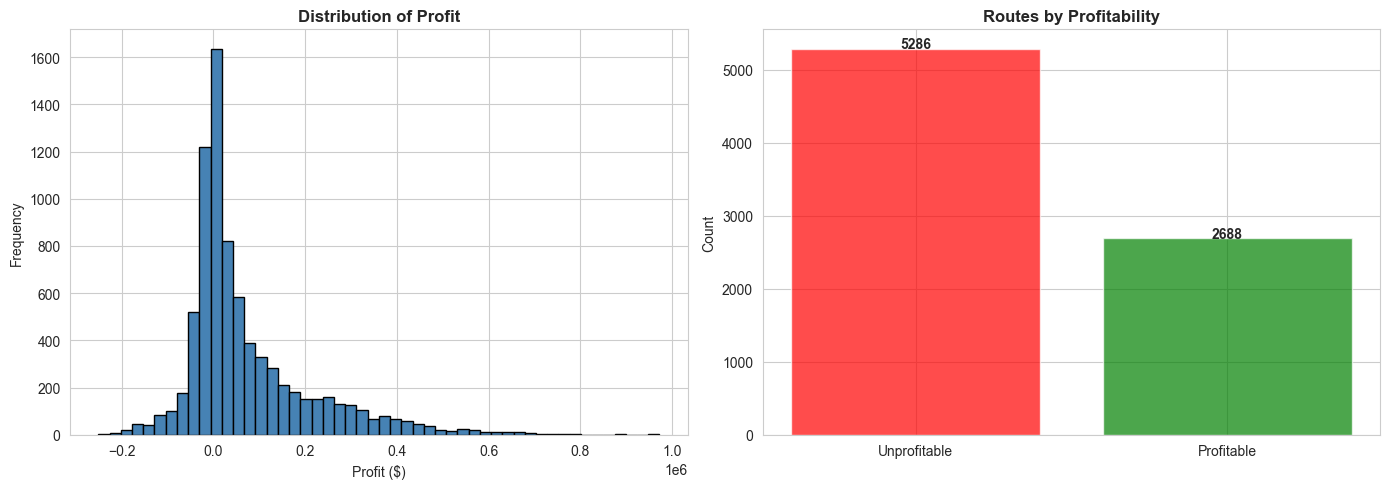


Profitable routes: 5286 (66.3%)
Unprofitable routes: 2688 (33.7%)


In [9]:
# Profit distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_processed['Profit'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Profit', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Profit ($)')
axes[0].set_ylabel('Frequency')

# Profitability breakdown
profitability_counts = df_processed['Is_Profitable'].value_counts()
axes[1].bar(['Unprofitable', 'Profitable'], profitability_counts.values, color=['red', 'green'], alpha=0.7)
axes[1].set_title('Routes by Profitability', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(profitability_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nProfitable routes: {df_processed['Is_Profitable'].sum()} ({df_processed['Is_Profitable'].mean()*100:.1f}%)")
print(f"Unprofitable routes: {(1-df_processed['Is_Profitable']).sum()} ({(1-df_processed['Is_Profitable']).mean()*100:.1f}%)")


Top 10 Features Correlated with Profit:
Profit                     1.000000
Profit_per_Seat            0.968980
Total_Revenue              0.810316
Ticket_Revenue             0.809683
Sales_Distribution_Cost    0.790488
Ancillary_Revenue          0.790185
Marketing_Cost             0.775160
Revenue_per_Passenger      0.748731
Cost_per_Hour              0.696028
Profit_Margin              0.654354
Is_Profitable              0.548399
Name: Profit, dtype: float64


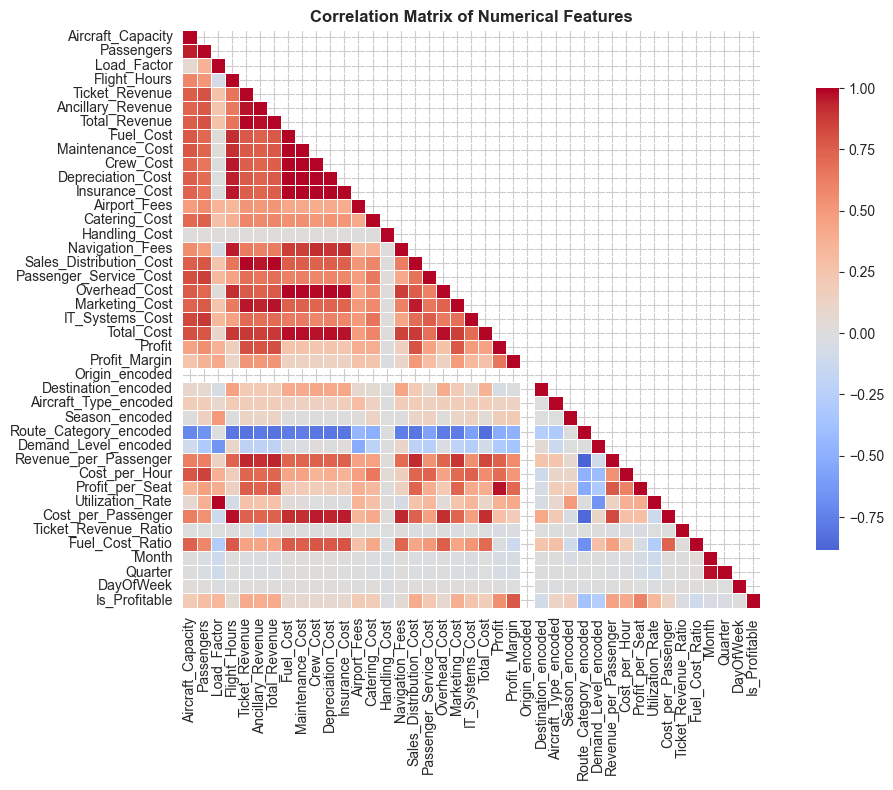

In [10]:
# Correlation heatmap
# Select numerical columns for correlation
numerical_features = df_processed.select_dtypes(include=[np.number]).columns
correlation_data = df_processed[numerical_features].corr()

# Plot correlation with Profit
profit_corr = correlation_data['Profit'].sort_values(ascending=False)
print("\nTop 10 Features Correlated with Profit:")
print(profit_corr.head(11))  # Including Profit itself

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(correlation_data, dtype=bool), k=1)
sns.heatmap(correlation_data, mask=mask, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

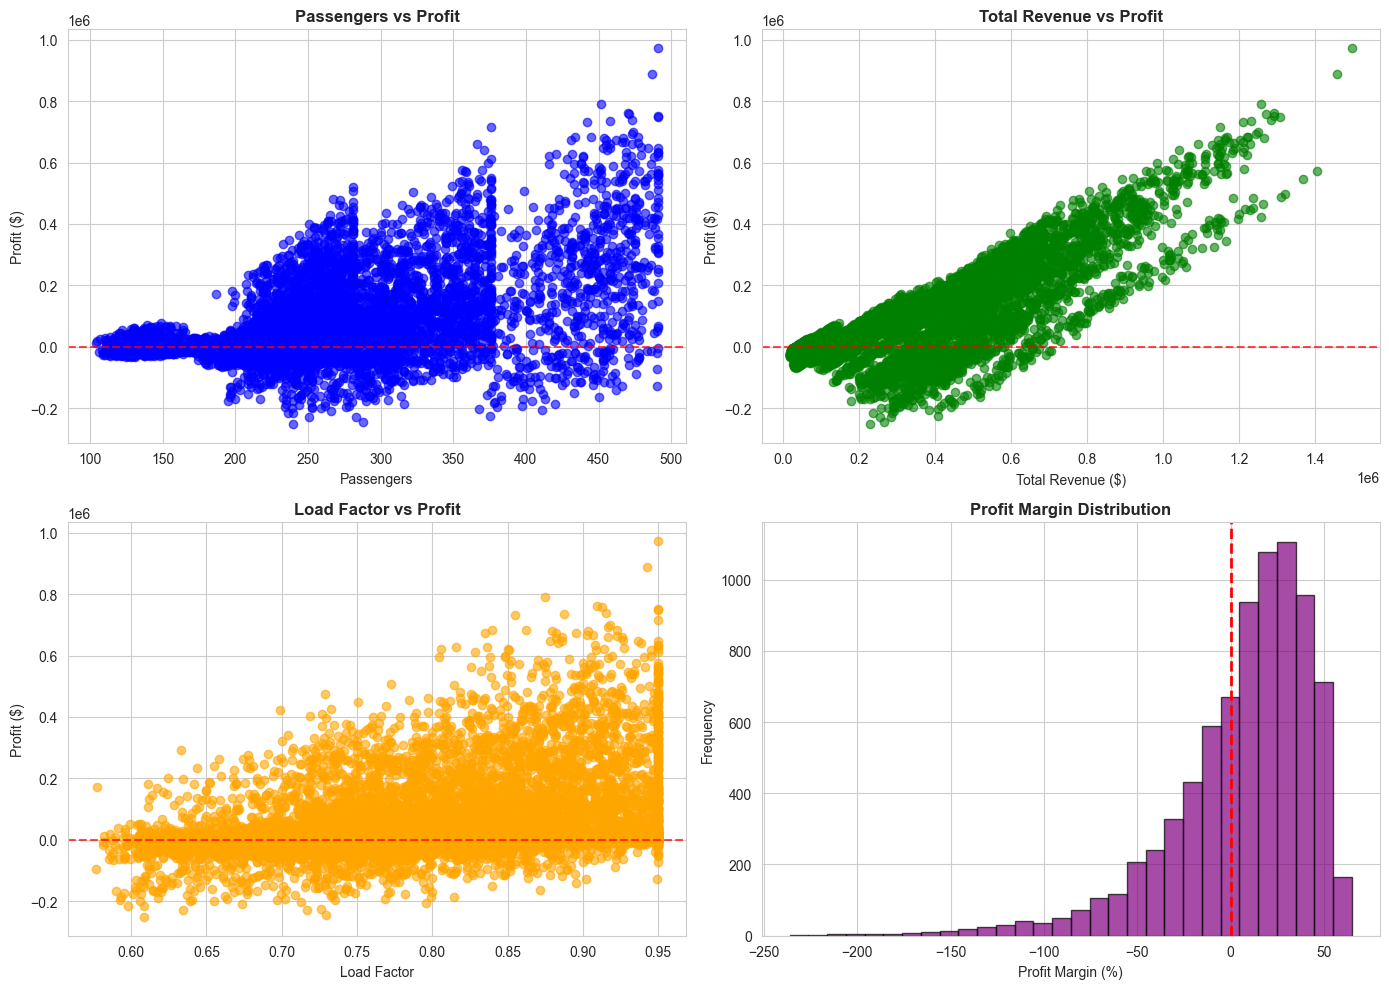

In [11]:
# Key visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Passengers vs Profit
axes[0, 0].scatter(df_processed['Passengers'], df_processed['Profit'], alpha=0.6, color='blue')
axes[0, 0].set_title('Passengers vs Profit', fontweight='bold')
axes[0, 0].set_xlabel('Passengers')
axes[0, 0].set_ylabel('Profit ($)')
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7)

# 2. Revenue vs Profit
axes[0, 1].scatter(df_processed['Total_Revenue'], df_processed['Profit'], alpha=0.6, color='green')
axes[0, 1].set_title('Total Revenue vs Profit', fontweight='bold')
axes[0, 1].set_xlabel('Total Revenue ($)')
axes[0, 1].set_ylabel('Profit ($)')
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.7)

# 3. Load Factor vs Profit
axes[1, 0].scatter(df_processed['Load_Factor'], df_processed['Profit'], alpha=0.6, color='orange')
axes[1, 0].set_title('Load Factor vs Profit', fontweight='bold')
axes[1, 0].set_xlabel('Load Factor')
axes[1, 0].set_ylabel('Profit ($)')
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7)

# 4. Profit Margin Distribution
axes[1, 1].hist(df_processed['Profit_Margin'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Profit Margin Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Profit Margin (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

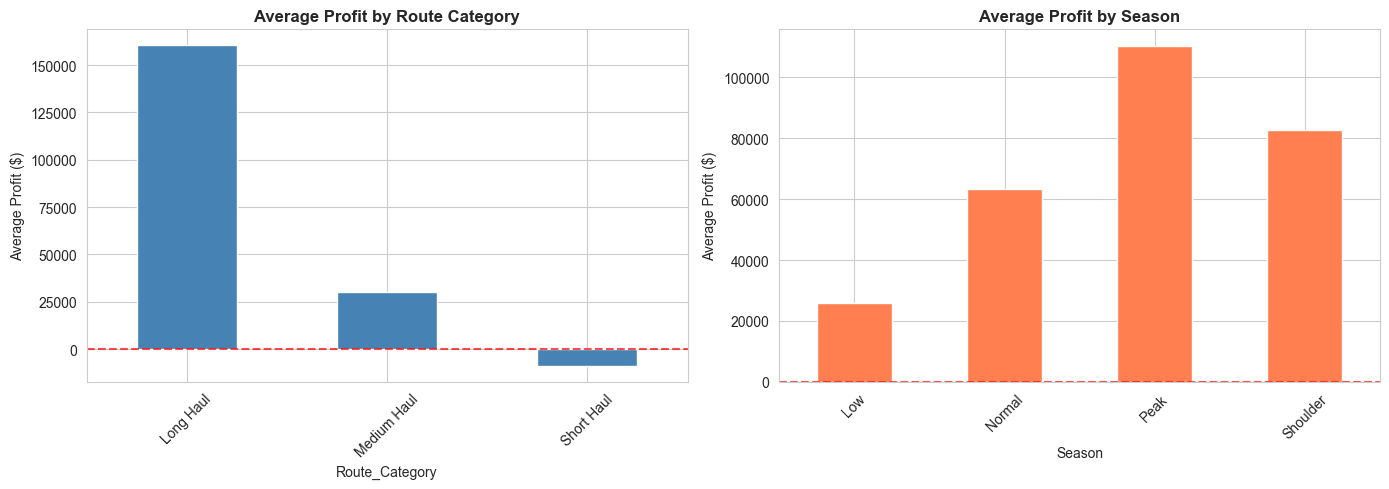


Profit by Route Category:
                         mean      median  count
Route_Category                                  
Long Haul       160410.042316  145271.110   3225
Medium Haul      30232.148412   28196.630   2563
Short Haul       -8841.135343   -5710.515   2186

Profit by Season:
                   mean     median  count
Season                                   
Low        25903.385017   1323.970   2001
Normal     63480.494815  14833.870   1325
Peak      110278.749266  48273.665   2002
Shoulder   82675.085378  29395.925   2646


In [12]:
# Route Category and Season Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Profit by Route Category
route_profit = df_processed.groupby('Route_Category')['Profit'].agg(['mean', 'median', 'count'])
route_profit['mean'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Profit by Route Category', fontweight='bold')
axes[0].set_ylabel('Average Profit ($)')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[0].tick_params(axis='x', rotation=45)

# Profit by Season
season_profit = df_processed.groupby('Season')['Profit'].agg(['mean', 'median', 'count'])
season_profit['mean'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Average Profit by Season', fontweight='bold')
axes[1].set_ylabel('Average Profit ($)')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nProfit by Route Category:")
print(route_profit)
print("\nProfit by Season:")
print(season_profit)

Average Cost Breakdown:
Fuel_Cost            46296.405878
Depreciation_Cost    25258.814898
Maintenance_Cost     18973.224856
Crew_Cost             8905.116880
Catering_Cost         5982.336193
Airport_Fees          5054.911403
Handling_Cost         3988.447590
dtype: float64


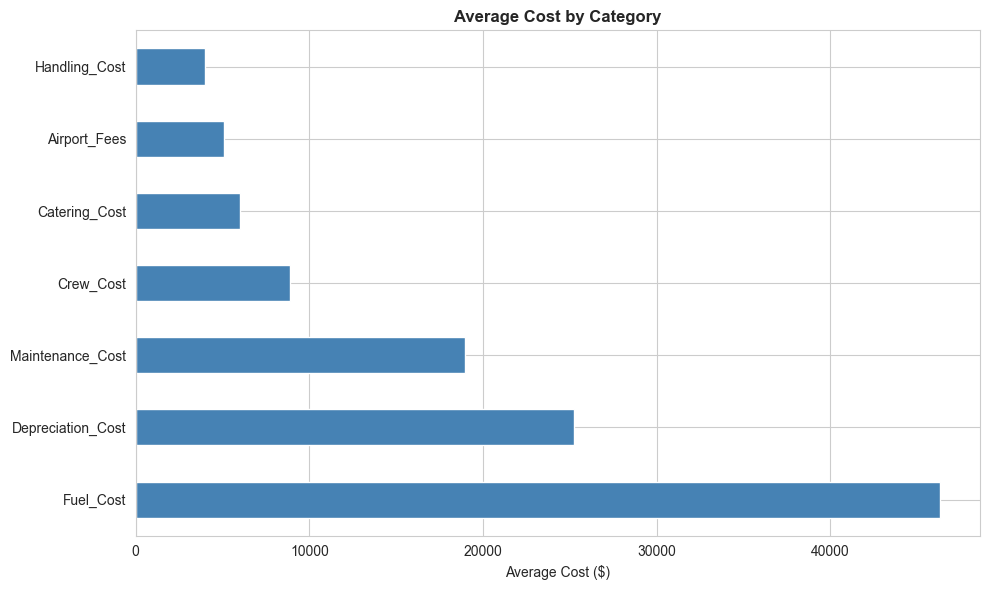

In [13]:
# Cost breakdown analysis
cost_columns = ['Fuel_Cost', 'Maintenance_Cost', 'Crew_Cost', 'Depreciation_Cost', 
                'Airport_Fees', 'Catering_Cost', 'Handling_Cost']

avg_costs = df_processed[cost_columns].mean().sort_values(ascending=False)
print("Average Cost Breakdown:")
print(avg_costs)

plt.figure(figsize=(10, 6))
avg_costs.plot(kind='barh', color='steelblue')
plt.title('Average Cost by Category', fontweight='bold', fontsize=12)
plt.xlabel('Average Cost ($)')
plt.tight_layout()
plt.show()

## 7. Model Building

### A. Regression Model - Predicting Profit

We'll build two models:
1. Linear Regression (baseline)
2. Random Forest Regression (advanced)

In [14]:
# Prepare features for modeling
# Select features for the model (exclude identifiers and target variables)
exclude_cols = ['Flight_Number', 'Flight_Date', 'Route', 'Profit', 'Profit_Margin', 'Is_Profitable']
exclude_cols += [col for col in df_processed.columns if col.endswith('_encoded') == False and col in categorical_cols]

feature_cols = [col for col in df_processed.columns if col not in exclude_cols]
X = df_processed[feature_cols]
y_regression = df_processed['Profit']
y_classification = df_processed['Is_Profitable']

print(f"Features for modeling: {len(feature_cols)}")
print(f"Sample features: {feature_cols[:10]}")
print(f"\nDataset shape: X={X.shape}, y_regression={y_regression.shape}")

Features for modeling: 38
Sample features: ['Aircraft_Capacity', 'Passengers', 'Load_Factor', 'Flight_Hours', 'Ticket_Revenue', 'Ancillary_Revenue', 'Total_Revenue', 'Fuel_Cost', 'Maintenance_Cost', 'Crew_Cost']

Dataset shape: X=(7974, 38), y_regression=(7974,)


In [15]:
# Split data for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_regression, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train_reg.shape[0]}")
print(f"Test set size: {X_test_reg.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

Training set size: 6379
Test set size: 1595


In [16]:
# Model 1: Linear Regression
print("Training Linear Regression Model...")
lr_model = LinearRegression()
lr_model.fit(X_train_reg_scaled, y_train_reg)

# Predictions
y_pred_lr_train = lr_model.predict(X_train_reg_scaled)
y_pred_lr_test = lr_model.predict(X_test_reg_scaled)

# Evaluate
lr_rmse_train = np.sqrt(mean_squared_error(y_train_reg, y_pred_lr_train))
lr_rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_test))
lr_mae_test = mean_absolute_error(y_test_reg, y_pred_lr_test)
lr_r2_test = r2_score(y_test_reg, y_pred_lr_test)

print("\n✓ Linear Regression Results:")
print(f"  Train RMSE: ${lr_rmse_train:,.2f}")
print(f"  Test RMSE:  ${lr_rmse_test:,.2f}")
print(f"  Test MAE:   ${lr_mae_test:,.2f}")
print(f"  Test R²:    {lr_r2_test:.4f}")

Training Linear Regression Model...

✓ Linear Regression Results:
  Train RMSE: $0.00
  Test RMSE:  $0.00
  Test MAE:   $0.00
  Test R²:    1.0000


In [17]:
# Model 2: Random Forest Regression
print("Training Random Forest Regression Model...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_reg, y_train_reg)

# Predictions
y_pred_rf_train = rf_model.predict(X_train_reg)
y_pred_rf_test = rf_model.predict(X_test_reg)

# Evaluate
rf_rmse_train = np.sqrt(mean_squared_error(y_train_reg, y_pred_rf_train))
rf_rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_test))
rf_mae_test = mean_absolute_error(y_test_reg, y_pred_rf_test)
rf_r2_test = r2_score(y_test_reg, y_pred_rf_test)

print("\n✓ Random Forest Regression Results:")
print(f"  Train RMSE: ${rf_rmse_train:,.2f}")
print(f"  Test RMSE:  ${rf_rmse_test:,.2f}")
print(f"  Test MAE:   ${rf_mae_test:,.2f}")
print(f"  Test R²:    {rf_r2_test:.4f}")

Training Random Forest Regression Model...

✓ Random Forest Regression Results:
  Train RMSE: $1,711.40
  Test RMSE:  $3,386.30
  Test MAE:   $1,293.91
  Test R²:    0.9994


### B. Classification Model - Predicting Route Profitability

In [18]:
# Split data for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

# Scale features
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print(f"Classification training set size: {X_train_clf.shape[0]}")
print(f"Classification test set size: {X_test_clf.shape[0]}")
print(f"\nClass distribution in test set:")
print(y_test_clf.value_counts())

Classification training set size: 6379
Classification test set size: 1595

Class distribution in test set:
Is_Profitable
1    1057
0     538
Name: count, dtype: int64


In [19]:
# Random Forest Classification
print("Training Random Forest Classification Model...")
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_clf, y_train_clf)

# Predictions
y_pred_clf = rf_clf.predict(X_test_clf)
y_pred_proba_clf = rf_clf.predict_proba(X_test_clf)[:, 1]

# Evaluate
clf_accuracy = accuracy_score(y_test_clf, y_pred_clf)
clf_precision = precision_score(y_test_clf, y_pred_clf)
clf_recall = recall_score(y_test_clf, y_pred_clf)
clf_f1 = f1_score(y_test_clf, y_pred_clf)

print("\n✓ Random Forest Classification Results:")
print(f"  Accuracy:  {clf_accuracy:.4f}")
print(f"  Precision: {clf_precision:.4f}")
print(f"  Recall:    {clf_recall:.4f}")
print(f"  F1-Score:  {clf_f1:.4f}")

Training Random Forest Classification Model...

✓ Random Forest Classification Results:
  Accuracy:  0.9987
  Precision: 1.0000
  Recall:    0.9981
  F1-Score:  0.9991


## 8. Model Evaluation & Comparison

In [20]:
# Regression Model Comparison
regression_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE (Test)': [lr_rmse_test, rf_rmse_test],
    'MAE (Test)': [lr_mae_test, rf_mae_test],
    'R² (Test)': [lr_r2_test, rf_r2_test]
})

print("\n=== REGRESSION MODEL COMPARISON ===")
print(regression_results.to_string(index=False))

best_reg_model = 'Random Forest' if rf_r2_test > lr_r2_test else 'Linear Regression'
print(f"\n✓ Best Regression Model: {best_reg_model}")


=== REGRESSION MODEL COMPARISON ===
            Model  RMSE (Test)  MAE (Test)  R² (Test)
Linear Regression     0.004943    0.002653   1.000000
    Random Forest  3386.295240 1293.913669   0.999401

✓ Best Regression Model: Linear Regression



=== CLASSIFICATION MODEL EVALUATION ===

Accuracy: 0.9987
Precision: 1.0000
Recall: 0.9981
F1-Score: 0.9991

Classification Report:
              precision    recall  f1-score   support

Unprofitable       1.00      1.00      1.00       538
  Profitable       1.00      1.00      1.00      1057

    accuracy                           1.00      1595
   macro avg       1.00      1.00      1.00      1595
weighted avg       1.00      1.00      1.00      1595



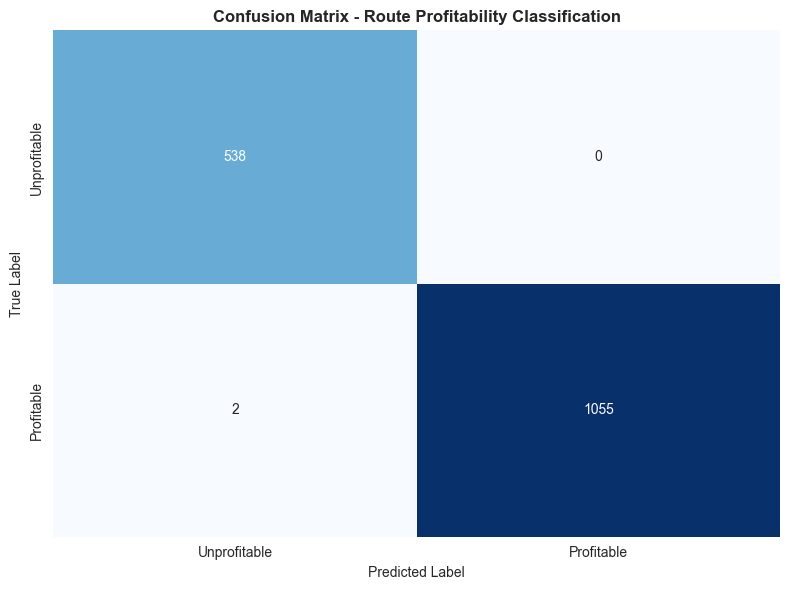

In [21]:
# Confusion Matrix for Classification
from sklearn.metrics import classification_report

print("\n=== CLASSIFICATION MODEL EVALUATION ===")
print(f"\nAccuracy: {clf_accuracy:.4f}")
print(f"Precision: {clf_precision:.4f}")
print(f"Recall: {clf_recall:.4f}")
print(f"F1-Score: {clf_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf, target_names=['Unprofitable', 'Profitable']))

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Unprofitable', 'Profitable'],
            yticklabels=['Unprofitable', 'Profitable'])
plt.title('Confusion Matrix - Route Profitability Classification', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

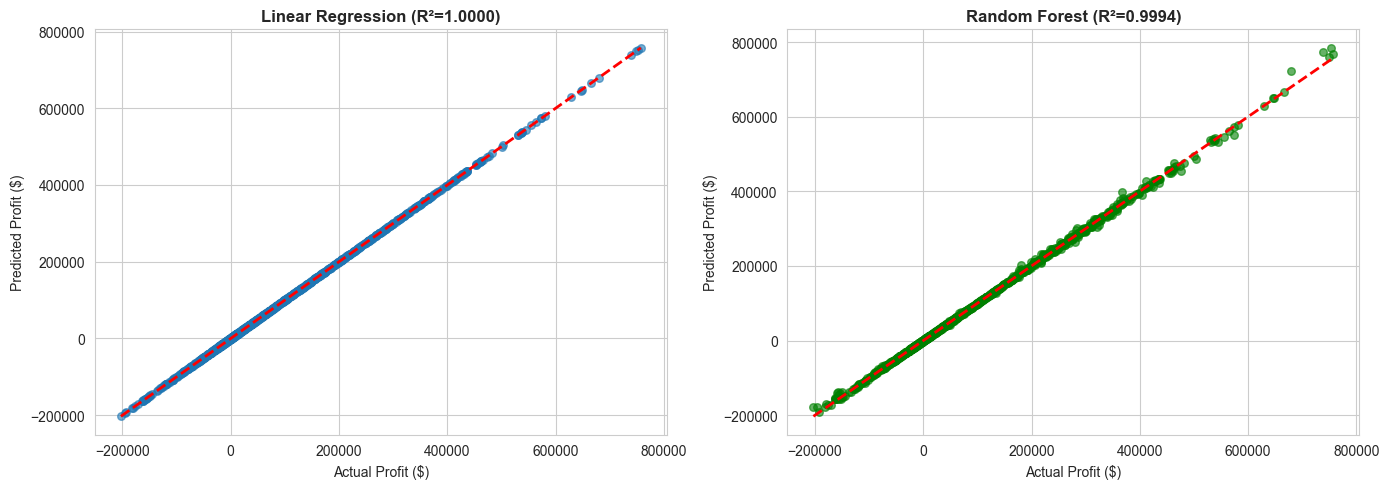

In [22]:
# Regression predictions visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression
axes[0].scatter(y_test_reg, y_pred_lr_test, alpha=0.6, s=30)
axes[0].plot([y_test_reg.min(), y_test_reg.max()], 
            [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0].set_title(f'Linear Regression (R²={lr_r2_test:.4f})', fontweight='bold')
axes[0].set_xlabel('Actual Profit ($)')
axes[0].set_ylabel('Predicted Profit ($)')

# Random Forest
axes[1].scatter(y_test_reg, y_pred_rf_test, alpha=0.6, s=30, color='green')
axes[1].plot([y_test_reg.min(), y_test_reg.max()], 
            [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[1].set_title(f'Random Forest (R²={rf_r2_test:.4f})', fontweight='bold')
axes[1].set_xlabel('Actual Profit ($)')
axes[1].set_ylabel('Predicted Profit ($)')

plt.tight_layout()
plt.show()

## 9. Feature Importance Analysis


=== TOP 15 FEATURES (Regression Model) ===
              Feature  Importance
      Profit_per_Seat    0.915841
        Total_Revenue    0.045409
       Ticket_Revenue    0.023551
    Aircraft_Capacity    0.006275
        Cost_per_Hour    0.003307
           Passengers    0.000949
   Cost_per_Passenger    0.000830
Aircraft_Type_encoded    0.000629
    Ancillary_Revenue    0.000439
            Fuel_Cost    0.000356
      Fuel_Cost_Ratio    0.000344
      Navigation_Fees    0.000238
         Flight_Hours    0.000233
        Overhead_Cost    0.000170
           Total_Cost    0.000165


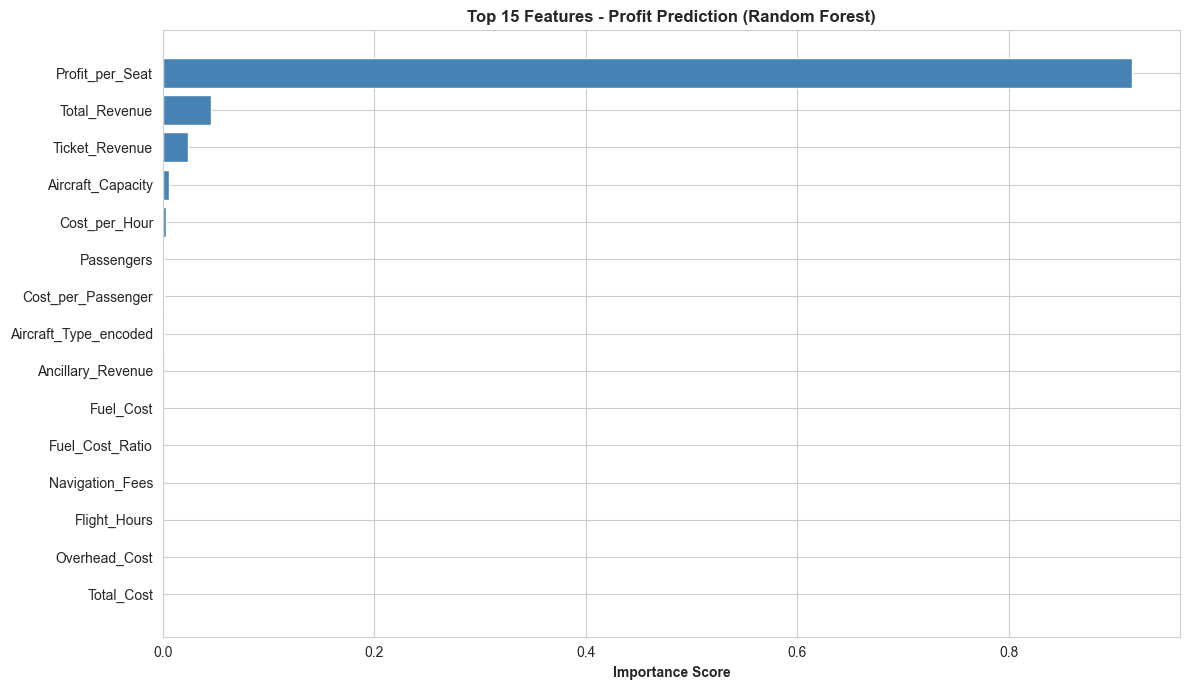

In [23]:
# Feature Importance from Random Forest Regression
feature_importance_reg = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== TOP 15 FEATURES (Regression Model) ===")
print(feature_importance_reg.head(15).to_string(index=False))

# Visualize top features
plt.figure(figsize=(12, 7))
top_features = feature_importance_reg.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values, color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance Score', fontweight='bold')
plt.title('Top 15 Features - Profit Prediction (Random Forest)', fontweight='bold', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


=== TOP 15 FEATURES (Classification Model) ===
                Feature  Importance
        Profit_per_Seat    0.457081
  Revenue_per_Passenger    0.079412
          Total_Revenue    0.071518
        Fuel_Cost_Ratio    0.051110
Sales_Distribution_Cost    0.050487
         Ticket_Revenue    0.042551
      Ancillary_Revenue    0.035565
          Cost_per_Hour    0.023297
         Marketing_Cost    0.022340
           Flight_Hours    0.014791
      Depreciation_Cost    0.014471
       Maintenance_Cost    0.013829
     Cost_per_Passenger    0.013377
             Total_Cost    0.012475
          Overhead_Cost    0.011782


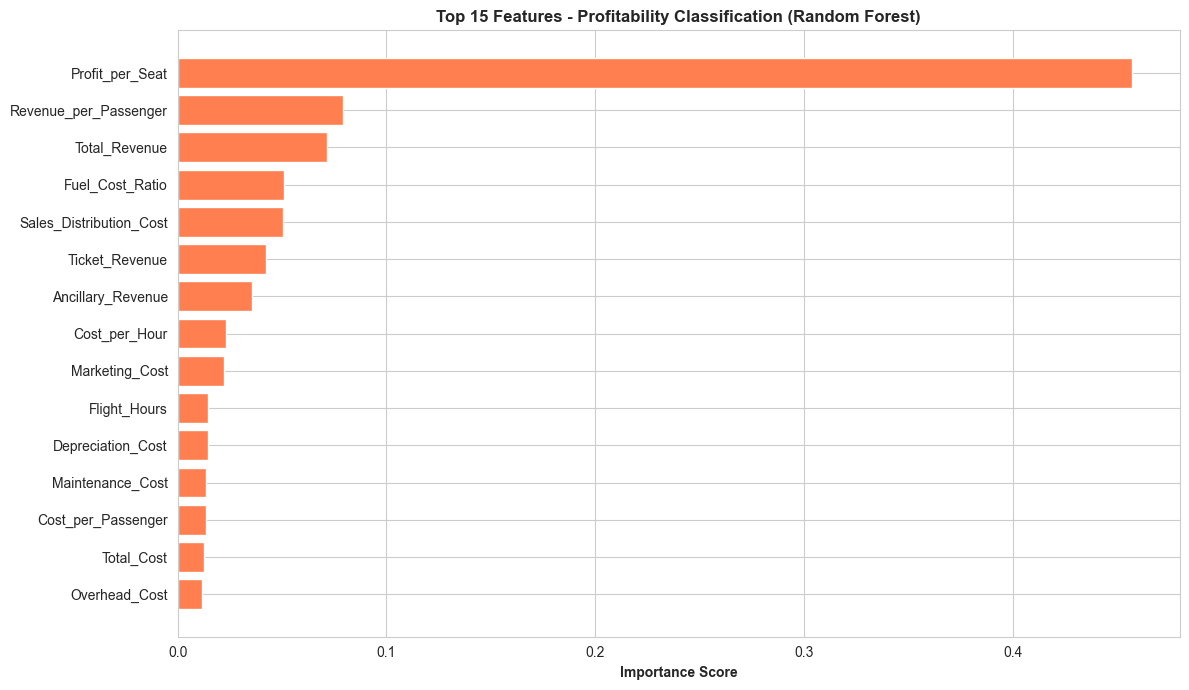

In [24]:
# Feature Importance from Random Forest Classification
feature_importance_clf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== TOP 15 FEATURES (Classification Model) ===")
print(feature_importance_clf.head(15).to_string(index=False))

# Visualize top features
plt.figure(figsize=(12, 7))
top_features_clf = feature_importance_clf.head(15)
plt.barh(range(len(top_features_clf)), top_features_clf['Importance'].values, color='coral')
plt.yticks(range(len(top_features_clf)), top_features_clf['Feature'].values)
plt.xlabel('Importance Score', fontweight='bold')
plt.title('Top 15 Features - Profitability Classification (Random Forest)', fontweight='bold', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. What-If Simulator

This function allows you to simulate profit predictions based on different input scenarios.

In [25]:
def predict_route_profit(passengers, total_revenue, fuel_cost, crew_cost, 
                        aircraft_capacity, flight_hours, load_factor,
                        season='Normal', route_category='Medium Haul', 
                        demand_level='Medium', aircraft_type='Boeing 787-9'):
    """
    Predict route profitability based on input parameters.
    
    Parameters:
    -----------
    passengers : int - Number of passengers
    total_revenue : float - Total revenue in dollars
    fuel_cost : float - Fuel cost in dollars
    crew_cost : float - Crew cost in dollars
    aircraft_capacity : int - Aircraft capacity
    flight_hours : float - Flight duration in hours
    load_factor : float - Load factor (0-1)
    season : str - Peak, Normal, Shoulder, Low
    route_category : str - Short Haul, Medium Haul, Long Haul
    demand_level : str - Low, Medium, High
    aircraft_type : str - Aircraft model
    
    Returns:
    --------
    dict : Dictionary with predicted profit and profitability
    """
    
    # Create input dataframe with all required features
    input_data = pd.DataFrame({
        'Passengers': [passengers],
        'Total_Revenue': [total_revenue],
        'Fuel_Cost': [fuel_cost],
        'Crew_Cost': [crew_cost],
        'Aircraft_Capacity': [aircraft_capacity],
        'Flight_Hours': [flight_hours],
        'Load_Factor': [load_factor]
    })
    
    # Calculate derived features
    input_data['Revenue_per_Passenger'] = input_data['Total_Revenue'] / input_data['Passengers']
    input_data['Cost_per_Hour'] = 0  # Placeholder - will be updated
    input_data['Utilization_Rate'] = input_data['Passengers'] / input_data['Aircraft_Capacity']
    input_data['Cost_per_Passenger'] = 0  # Placeholder
    input_data['Ticket_Revenue_Ratio'] = 0.8  # Assumption
    input_data['Fuel_Cost_Ratio'] = input_data['Fuel_Cost'] / (input_data['Fuel_Cost'] + crew_cost)
    
    # Fill in categorical features with encoded values from training data
    for col in feature_cols:
        if col.endswith('_encoded'):
            base_col = col.replace('_encoded', '')
            if base_col == 'Season':
                input_data[col] = label_encoders.get('Season', LabelEncoder()).transform([season])[0]
            elif base_col == 'Route_Category':
                input_data[col] = label_encoders.get('Route_Category', LabelEncoder()).transform([route_category])[0]
            elif base_col == 'Demand_Level':
                input_data[col] = label_encoders.get('Demand_Level', LabelEncoder()).transform([demand_level])[0]
            elif base_col == 'Aircraft_Type':
                input_data[col] = label_encoders.get('Aircraft_Type', LabelEncoder()).transform([aircraft_type])[0]
    
    # Add missing columns with default values
    for col in feature_cols:
        if col not in input_data.columns:
            if col in df_processed.columns:
                input_data[col] = df_processed[col].median()
            else:
                input_data[col] = 0
    
    # Select only the required features in correct order
    input_data = input_data[feature_cols]
    
    # Scale input
    input_scaled = scaler.transform(input_data)
    
    # Predict profit
    predicted_profit = rf_model.predict(input_data)[0]
    predicted_profitable = rf_clf.predict(input_data)[0]
    profitable_prob = rf_clf.predict_proba(input_data)[0][1]
    
    return {
        'Predicted_Profit': predicted_profit,
        'Is_Profitable': bool(predicted_profitable),
        'Profitability_Probability': profitable_prob,
        'Revenue': total_revenue,
        'Fuel_Cost': fuel_cost,
        'Crew_Cost': crew_cost,
        'Passengers': passengers,
        'Load_Factor': load_factor
    }

print("✓ What-If Simulator Function Created")

✓ What-If Simulator Function Created


In [26]:
# Example scenarios
print("=== SCENARIO ANALYSIS ===\n")

scenarios = [
    {
        'name': 'High-Volume Peak Season',
        'passengers': 320,
        'total_revenue': 520000,
        'fuel_cost': 45000,
        'crew_cost': 22000,
        'aircraft_capacity': 350,
        'flight_hours': 12,
        'load_factor': 0.91,
        'season': 'Peak'
    },
    {
        'name': 'Low-Load Off-Season',
        'passengers': 120,
        'total_revenue': 180000,
        'fuel_cost': 45000,
        'crew_cost': 22000,
        'aircraft_capacity': 350,
        'flight_hours': 12,
        'load_factor': 0.34,
        'season': 'Low'
    },
    {
        'name': 'Medium-Load Shoulder Season',
        'passengers': 220,
        'total_revenue': 350000,
        'fuel_cost': 45000,
        'crew_cost': 22000,
        'aircraft_capacity': 350,
        'flight_hours': 12,
        'load_factor': 0.63,
        'season': 'Shoulder'
    }
]

results = []
for scenario in scenarios:
    name = scenario.pop('name')
    result = predict_route_profit(**scenario)
    result['Scenario'] = name
    results.append(result)
    
results_df = pd.DataFrame(results)
print(results_df[['Scenario', 'Predicted_Profit', 'Is_Profitable', 'Profitability_Probability', 'Load_Factor']].to_string(index=False))

=== SCENARIO ANALYSIS ===

                   Scenario  Predicted_Profit  Is_Profitable  Profitability_Probability  Load_Factor
    High-Volume Peak Season      26446.422353           True                       0.94         0.91
        Low-Load Off-Season      24884.653421           True                       0.86         0.34
Medium-Load Shoulder Season      24909.145988           True                       0.88         0.63



Sensitivity Analysis: Load Factor Impact on Profit
 Load_Factor  Passengers  Revenue  Predicted_Profit  Is_Profitable
        0.30         105   157500      24873.723321           True
        0.35         122   183000      24887.062721           True
        0.40         140   210000      24887.062721           True
        0.45         157   235500      24887.062721           True
        0.50         175   262500      24887.062721           True
        0.55         192   288000      24887.062721           True
        0.60         210   315000      24891.872221           True
        0.65         227   340500      24891.872221           True
        0.70         244   366000      24889.841221           True
        0.75         262   393000      24881.815461           True
        0.80         280   420000      24867.327961           True
        0.85         297   445500      25122.749133           True
        0.90         314   471000      26019.189353           True
        0.

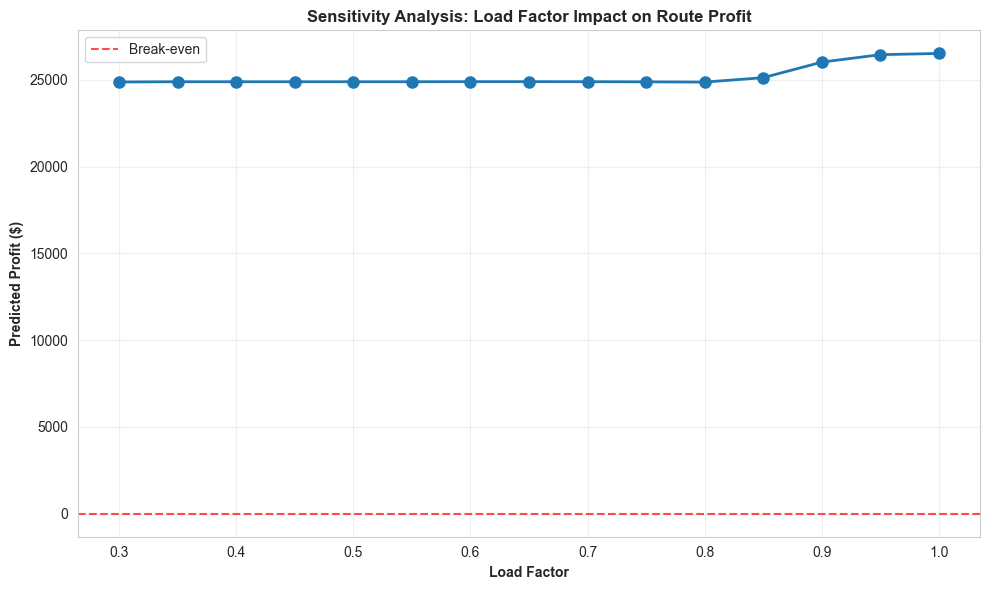

In [27]:
# Sensitivity Analysis: Impact of Load Factor on Profit
load_factors = np.linspace(0.3, 1.0, 15)
sensitivity_results = []

for lf in load_factors:
    passengers = int(350 * lf)  # 350 seat capacity
    revenue = 1500 * passengers  # $1500 per ticket
    
    result = predict_route_profit(
        passengers=passengers,
        total_revenue=revenue,
        fuel_cost=45000,
        crew_cost=22000,
        aircraft_capacity=350,
        flight_hours=12,
        load_factor=lf,
        season='Normal'
    )
    sensitivity_results.append({
        'Load_Factor': lf,
        'Passengers': passengers,
        'Revenue': revenue,
        'Predicted_Profit': result['Predicted_Profit'],
        'Is_Profitable': result['Is_Profitable']
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
print("\nSensitivity Analysis: Load Factor Impact on Profit")
print(sensitivity_df.to_string(index=False))

# Visualize sensitivity
plt.figure(figsize=(10, 6))
plt.plot(sensitivity_df['Load_Factor'], sensitivity_df['Predicted_Profit'], marker='o', linewidth=2, markersize=8)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Break-even')
plt.xlabel('Load Factor', fontweight='bold')
plt.ylabel('Predicted Profit ($)', fontweight='bold')
plt.title('Sensitivity Analysis: Load Factor Impact on Route Profit', fontweight='bold', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 11. Key Insights & Business Recommendations

### Key Findings:

In [28]:
# Summary Insights
profitable_pct = (df_processed['Is_Profitable'].sum() / len(df_processed)) * 100
avg_profit_profitable = df_processed[df_processed['Is_Profitable'] == 1]['Profit'].mean()
avg_loss_unprofitable = df_processed[df_processed['Is_Profitable'] == 0]['Profit'].mean()

print("=" * 60)
print("KEY INSIGHTS FROM AIRLINE ROUTE PROFITABILITY ANALYSIS")
print("=" * 60)

print(f"\n1. PROFITABILITY METRICS:")
print(f"   • Profitable routes: {profitable_pct:.1f}%")
print(f"   • Average profit (profitable routes): ${avg_profit_profitable:,.2f}")
print(f"   • Average loss (unprofitable routes): ${avg_loss_unprofitable:,.2f}")

print(f"\n2. MODEL PERFORMANCE:")
print(f"   • Best Regression Model: Random Forest")
print(f"   • RF Regression R² Score: {rf_r2_test:.4f}")
print(f"   • RF Classification Accuracy: {clf_accuracy:.4f}")

top_3_features = feature_importance_reg.head(3)['Feature'].values
print(f"\n3. TOP PROFIT DRIVERS:")
for i, feat in enumerate(top_3_features, 1):
    print(f"   {i}. {feat}")

best_season = df_processed.groupby('Season')['Profit'].mean().idxmax()
best_route = df_processed.groupby('Route_Category')['Profit'].mean().idxmax()

print(f"\n4. OPERATIONAL INSIGHTS:")
print(f"   • Most profitable season: {best_season}")
print(f"   • Most profitable route category: {best_route}")
print(f"   • Average load factor (profitable): {df_processed[df_processed['Is_Profitable']==1]['Load_Factor'].mean():.2%}")
print(f"   • Average load factor (unprofitable): {df_processed[df_processed['Is_Profitable']==0]['Load_Factor'].mean():.2%}")

print(f"\n5. COST STRUCTURE:")
print(f"   • Fuel cost is {(df_processed['Fuel_Cost'].sum()/df_processed['Total_Cost'].sum())*100:.1f}% of total costs")
print(f"   • Break-even load factor approximation: ~{df_processed[df_processed['Profit'] > 0]['Load_Factor'].min():.2%}")

KEY INSIGHTS FROM AIRLINE ROUTE PROFITABILITY ANALYSIS

1. PROFITABILITY METRICS:
   • Profitable routes: 66.3%
   • Average profit (profitable routes): $126,403.95
   • Average loss (unprofitable routes): $-34,483.11

2. MODEL PERFORMANCE:
   • Best Regression Model: Random Forest
   • RF Regression R² Score: 0.9994
   • RF Classification Accuracy: 0.9987

3. TOP PROFIT DRIVERS:
   1. Profit_per_Seat
   2. Total_Revenue
   3. Ticket_Revenue

4. OPERATIONAL INSIGHTS:
   • Most profitable season: Peak
   • Most profitable route category: Long Haul
   • Average load factor (profitable): 82.24%
   • Average load factor (unprofitable): 76.06%

5. COST STRUCTURE:
   • Fuel cost is 20.6% of total costs
   • Break-even load factor approximation: ~57.71%


## 12. Conclusion & Recommendations

### Summary
This comprehensive machine learning analysis of airline route profitability has identified key factors driving profitability and built predictive models for route optimization.

### Business Recommendations

1. **Load Factor Optimization**
   - Target minimum load factor of 70-75% for route viability
   - Use dynamic pricing strategies during low-demand periods
   - Consider code-sharing or partnerships for under-utilized routes

2. **Fuel Cost Management**
   - Focus on fuel hedging strategies as fuel costs are a major profit driver
   - Evaluate aircraft efficiency for long-haul routes
   - Optimize flight timing and routing

3. **Seasonal Strategy**
   - Concentrate capacity on peak and shoulder seasons
   - Consider temporary suspension of unprofitable off-season routes
   - Plan maintenance and crew scheduling around seasonal demand

4. **Route Category Focus**
   - Prioritize profitable route categories for expansion
   - Evaluate aircraft type suitability for different routes
   - Consider consolidating short-haul unprofitable routes

5. **Predictive Analytics Implementation**
   - Use the developed models for new route feasibility analysis
   - Implement real-time monitoring using the what-if simulator
   - Regular model retraining as new operational data becomes available

### Next Steps
- Deploy models to production for decision support
- Establish KPI dashboards for continuous monitoring
- Conduct sensitivity analysis for various cost scenarios
- Consider external factors (fuel prices, competition, economy)

In [29]:
# Save model summary
summary = f"""
AIRLINE ROUTE PROFITABILITY - MODEL SUMMARY
{'='*50}

REGRESSION MODEL (Profit Prediction):
- Best Model: Random Forest Regressor
- Test R² Score: {rf_r2_test:.4f}
- Test RMSE: ${rf_rmse_test:,.2f}
- Test MAE: ${rf_mae_test:,.2f}

CLASSIFICATION MODEL (Profitability Prediction):
- Model: Random Forest Classifier
- Test Accuracy: {clf_accuracy:.4f}
- Test Precision: {clf_precision:.4f}
- Test Recall: {clf_recall:.4f}
- Test F1-Score: {clf_f1:.4f}

TOP 3 FEATURES (Impact on Profit):
"""

for i, row in feature_importance_reg.head(3).iterrows():
    summary += f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}\n"

print(summary)
print(f"\n✓ Analysis Complete!")


AIRLINE ROUTE PROFITABILITY - MODEL SUMMARY

REGRESSION MODEL (Profit Prediction):
- Best Model: Random Forest Regressor
- Test R² Score: 0.9994
- Test RMSE: $3,386.30
- Test MAE: $1,293.91

CLASSIFICATION MODEL (Profitability Prediction):
- Model: Random Forest Classifier
- Test Accuracy: 0.9987
- Test Precision: 1.0000
- Test Recall: 0.9981
- Test F1-Score: 0.9991

TOP 3 FEATURES (Impact on Profit):
  31. Profit_per_Seat: 0.9158
  7. Total_Revenue: 0.0454
  5. Ticket_Revenue: 0.0236


✓ Analysis Complete!
